# Machine Learning Model Implementation using Scikit-Learn

## Iris Flower Classification

### COMPANY: CODTECH IT SOLUTIONS

### NAME: TUHIN ROY

### INTERN ID: CTIS05SQ

### DOMAIN: PYTHON

### DURATION: 4 WEEKS

### MENTOR: NEELA SANTOSH

# Project Introduction

Machine Learning is a branch of Artificial Intelligence that enables computers to learn from data and make predictions.

The Iris Flower Classification dataset is one of the most popular datasets in machine learning. The goal is to classify iris flowers into three species based on flower measurements.

# Problem Statement

Develop a machine learning model capable of classifying iris flowers into three species:

1. Iris Setosa
2. Iris Versicolor
3. Iris Virginica

using flower measurements.

In [4]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

# Dataset Loading

In [5]:
iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

y = pd.Series(
    iris.target
)

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (150, 4)
Target Shape: (150,)


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [8]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


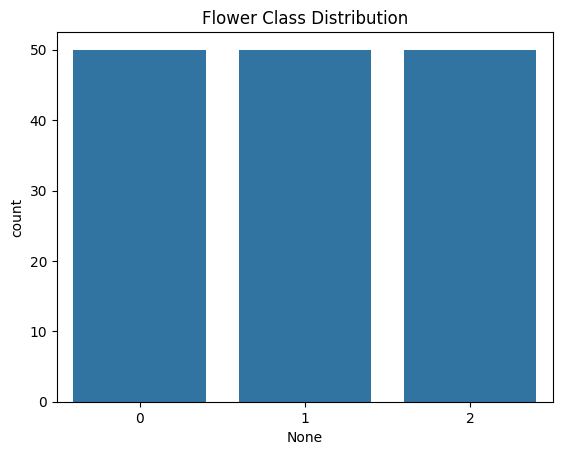

In [9]:
sns.countplot(x=y)

plt.title("Flower Class Distribution")

plt.show()

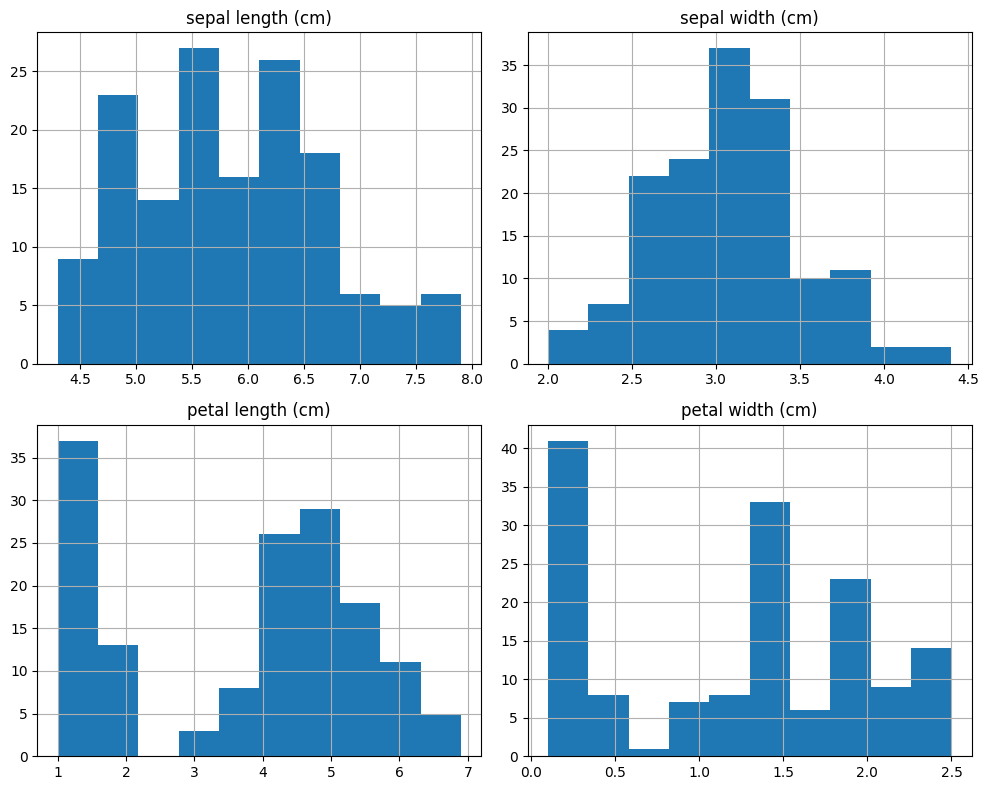

In [10]:
X.hist(figsize=(10,8))

plt.tight_layout()

plt.show()

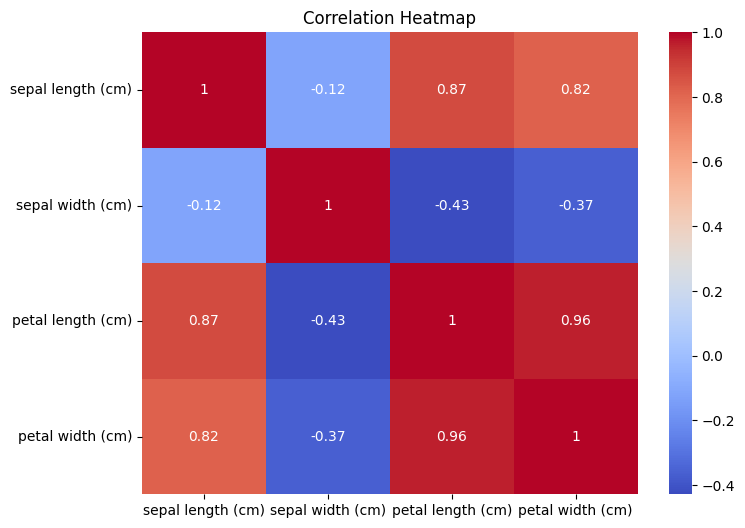

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

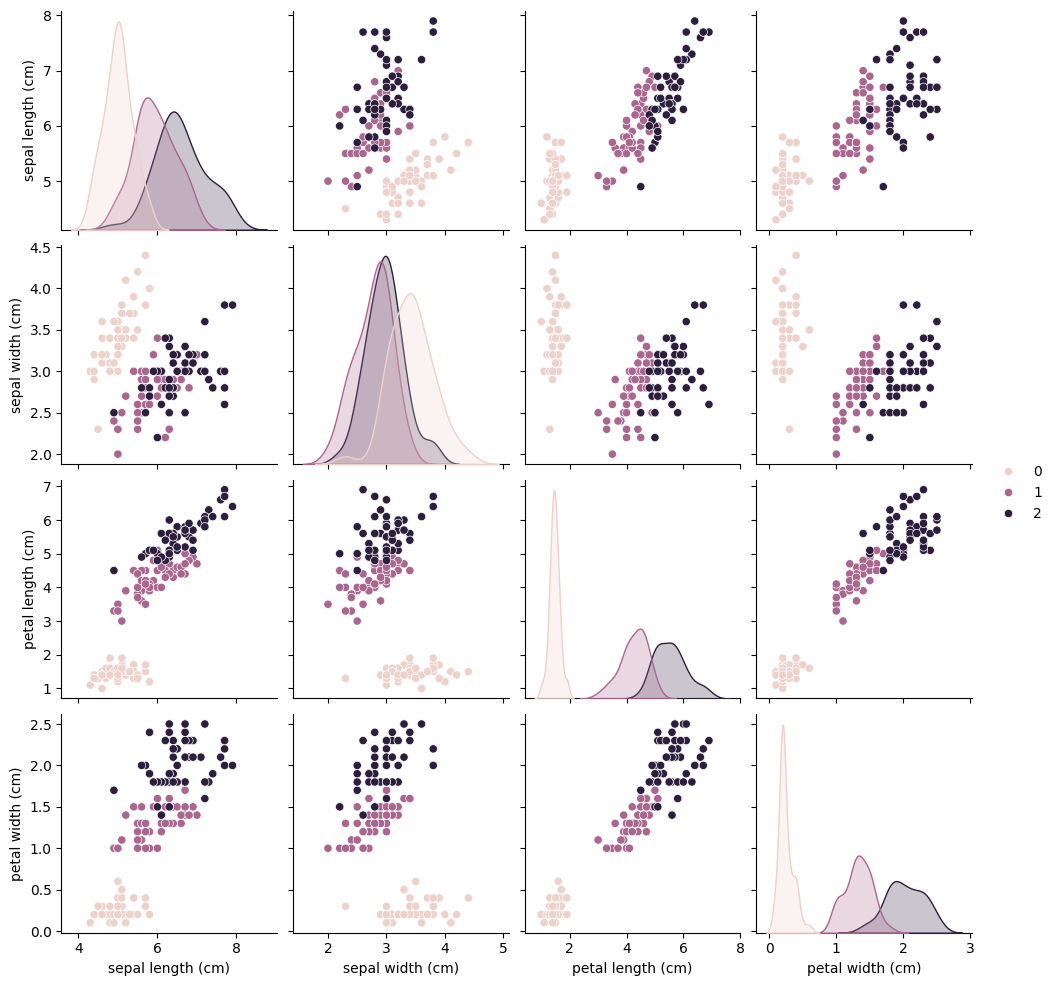

In [12]:
sns.pairplot(
    pd.concat([X,y],axis=1),
    hue=0
)

plt.show()

# Data Preprocessing

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(120, 4)
(30, 4)


# Logistic Regression

In [15]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

# Random Forest

In [16]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

# Support Vector Machine

In [17]:
svm = SVC()

svm.fit(X_train,y_train)

svm_pred = svm.predict(X_test)

In [18]:
def evaluate_model(name,predictions):

    print(name)

    print("-"*30)

    print(
        "Accuracy:",
        accuracy_score(
            y_test,
            predictions
        )
    )

    print()

    print(
        classification_report(
            y_test,
            predictions
        )
    )

In [19]:
evaluate_model(
    "Logistic Regression",
    lr_pred
)

Logistic Regression
------------------------------
Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [20]:
evaluate_model(
    "Random Forest",
    rf_pred
)

Random Forest
------------------------------
Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
evaluate_model(
    "SVM",
    svm_pred
)

SVM
------------------------------
Accuracy: 1.0

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



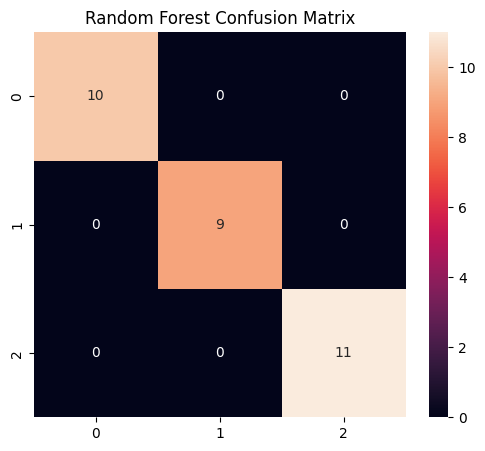

In [22]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

In [23]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            svm_pred
        )
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0
2,SVM,1.0


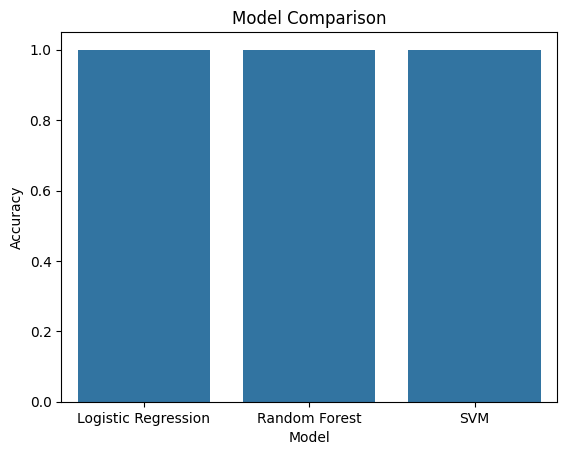

In [24]:
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title(
    "Model Comparison"
)

plt.show()

In [25]:
param_grid = {

    'n_estimators':[50,100,150],

    'max_depth':[3,5,10]
}

In [26]:
grid = GridSearchCV(

    RandomForestClassifier(),

    param_grid,

    cv=5
)

grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [27]:
print(
    grid.best_params_
)

print(
    grid.best_score_
)

{'max_depth': 10, 'n_estimators': 100}
0.9583333333333334


In [28]:
sample = X_test[0].reshape(1,-1)

prediction = grid.predict(sample)

flower_name = iris.target_names[
    prediction[0]
]

print(
    "Predicted Flower:",
    flower_name
)

Predicted Flower: versicolor


# Conclusion

This project successfully implemented machine learning algorithms for Iris flower classification.

The models were trained and evaluated using Scikit-Learn. Random Forest, Logistic Regression, and SVM achieved high classification accuracy.

The project demonstrates how machine learning can be used to classify data and make predictions efficiently.